In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
%matplotlib inline
print("✅ Librerías cargadas")

✅ Librerías cargadas


In [5]:
df = pd.read_csv('C:\\Users\\HP\\Documents\\EDWIN\\AUTOCAD\\PHYTON\\Proyecto 1\\AEP_hourly.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').set_index('Datetime')
df_daily = df.resample('D').mean()

# Normalizar entre 0 y 1 (LSTM requiere esto)
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_daily[['AEP_MW']])

print(f"✅ Datos normalizados: {scaled_data.shape}")

✅ Datos normalizados: (5055, 1)


In [7]:
def create_sequences(data, window=60):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# Usamos ventana de 60 días
X, y = create_sequences(scaled_data, window=60)

# Reshape para LSTM [samples, timesteps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)

print(f"✅ X shape: {X.shape}")
print(f"✅ y shape: {y.shape}")

✅ X shape: (4995, 60, 1)
✅ y shape: (4995,)


In [9]:
split = int(len(X) * 0.85)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"✅ Train: {X_train.shape[0]} muestras")
print(f"✅ Test:  {X_test.shape[0]} muestras")

✅ Train: 4245 muestras
✅ Test:  750 muestras


In [11]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(60, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
print("✅ Modelo entrenado")

Epoch 1/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - loss: 0.0207 - val_loss: 0.0134
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0159 - val_loss: 0.0129
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0156 - val_loss: 0.0130
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0145 - val_loss: 0.0124
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0143 - val_loss: 0.0120
Epoch 6/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0135 - val_loss: 0.0114
Epoch 7/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0133 - val_loss: 0.0115
Epoch 8/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0123 - val_loss: 0.0099
Epoch 9/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.0105 - val_loss: 0.0087
Epoch 10/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0092 - val_loss: 0.0074
Epoch 11/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0082 - val_loss: 0.0066
Epoch 12/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 

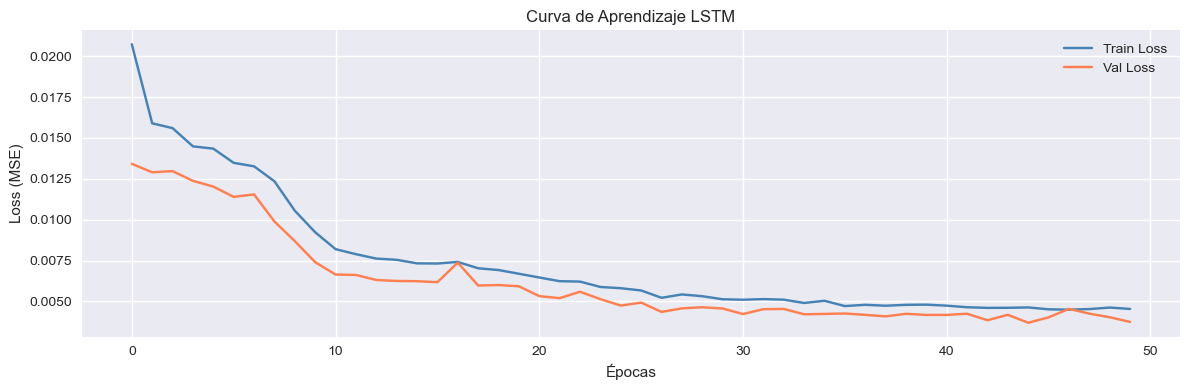

In [15]:
plt.figure(figsize=(12, 4))
plt.plot(history.history['loss'], label='Train Loss', color='steelblue')
plt.plot(history.history['val_loss'], label='Val Loss', color='coral')
plt.title('Curva de Aprendizaje LSTM')
plt.xlabel('Épocas')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
pred_scaled = model.predict(X_test)

# Desnormalizar
pred = scaler.inverse_transform(pred_scaled)
real = scaler.inverse_transform(y_test.reshape(-1, 1))

mae = mean_absolute_error(real, pred)
rmse = np.sqrt(mean_squared_error(real, pred))
mape = np.mean(np.abs((real - pred) / real)) * 100

print(f"📊 Métricas del modelo LSTM:")
print(f"   MAE:  {mae:.2f} MW")
print(f"   RMSE: {rmse:.2f} MW")
print(f"   MAPE: {mape:.2f}%")

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
📊 Métricas del modelo LSTM:
   MAE:  556.50 MW
   RMSE: 728.35 MW
   MAPE: 3.72%


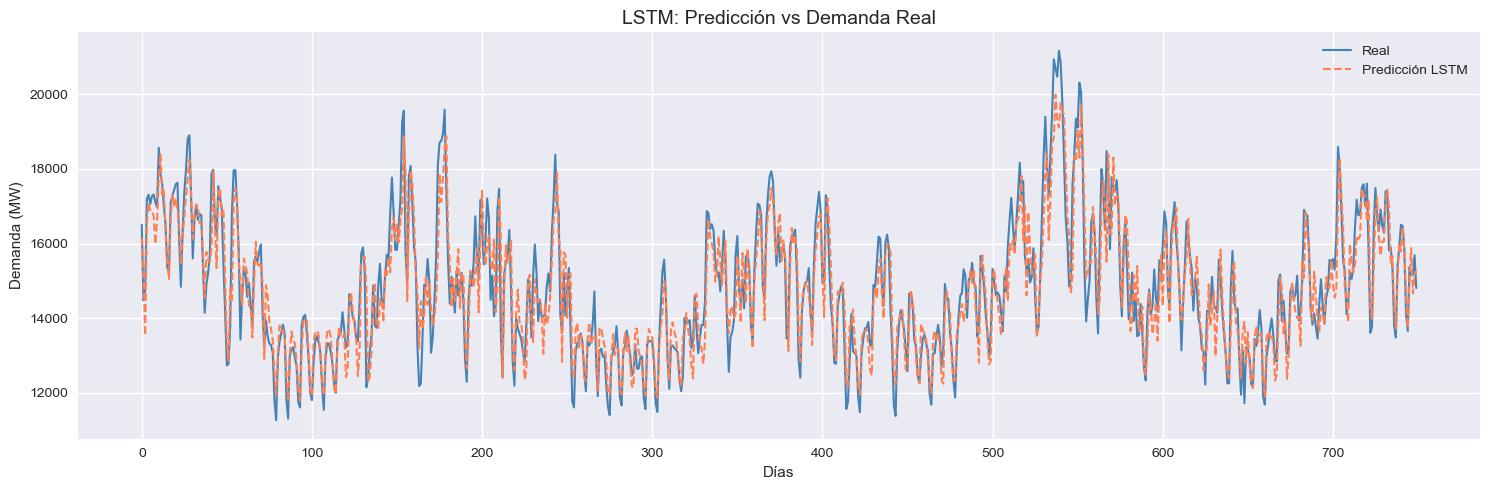

In [19]:
plt.figure(figsize=(15, 5))
plt.plot(real, label='Real', color='steelblue', linewidth=1.5)
plt.plot(pred, label='Predicción LSTM', color='coral', 
         linewidth=1.5, linestyle='--')
plt.title('LSTM: Predicción vs Demanda Real', fontsize=14)
plt.xlabel('Días')
plt.ylabel('Demanda (MW)')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# En el notebook, reemplaza la celda de guardar por esto:
model.save('lstm_energy_model.keras')
print("✅ Modelo guardado en formato nuevo")

✅ Modelo guardado en formato nuevo
